# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

### EDA plots
Dataset source: [Kaggle, version 1](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/versions/1).

Install if needed: `%pip install "kagglehub[pandas-datasets]" matplotlib`

The plots show associations in this sample, not causal effects or calibrated clinical predictions. Counts are shown to help assess small groups. No rows are dropped or imputed for these plots. The written interpretation is left for you.


In [ ]:
from pathlib import Path
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


#importing dataset


# The path is the filename inside the Kaggle dataset, not an empty string.
csv_path = Path("heart.csv")
if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "fedesoriano/heart-failure-prediction/versions/1",
        "heart.csv",
    )
    df.to_csv(csv_path, index=False)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
display(df.isna().sum().rename("Missing values").to_frame())
display(df[numeric_cols].describe())
display(df[numeric_cols].eq(0).sum().rename("Zero values").to_frame())
print("Duplicate rows:", df.duplicated().sum())
print("Columns:", df.columns.tolist())
# These four plots use no BP or cholesterol values; no rows are dropped or imputed.


,Missing values
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


,Zero values
Age,0
RestingBP,1
Cholesterol,172
MaxHR,0
Oldpeak,368


Duplicate rows: 0
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

plt.close("all")

plot_dir = Path("plots")
plot_dir.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})
colors = ["#3979A8", "#C35A45"]


Plot 1: Do the age distributions overlap? Compare their shapes; each outcome group is normalized separately.

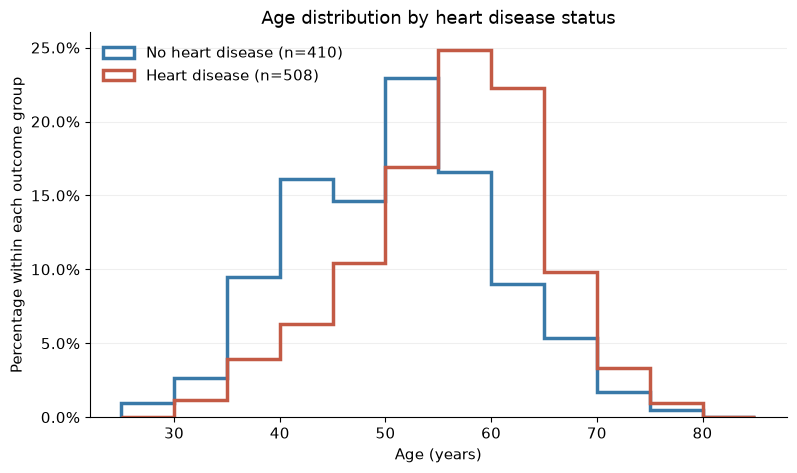

In [25]:
# Common bin edges and within-class percentages allow a fair shape comparison.
fig, ax = plt.subplots(figsize=(9, 5))
bins = list(range(25, 86, 5))
for outcome, label, color in [(0, "No heart disease", colors[0]),
                              (1, "Heart disease", colors[1])]:
    ages = df.loc[df["HeartDisease"].eq(outcome), "Age"].dropna()
    ax.hist(ages, bins=bins, weights=[100 / len(ages)] * len(ages),
            histtype="step", linewidth=2.5, color=color,
            label=f"{label} (n={len(ages)})")
ax.set(title="Age distribution by heart disease status",
       xlabel="Age (years)", ylabel="Percentage within each outcome group")
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)

plt.show()
plt.close(fig)

Plot 2: Compare within-category percentages rather than raw counts. Which categories have smaller samples?

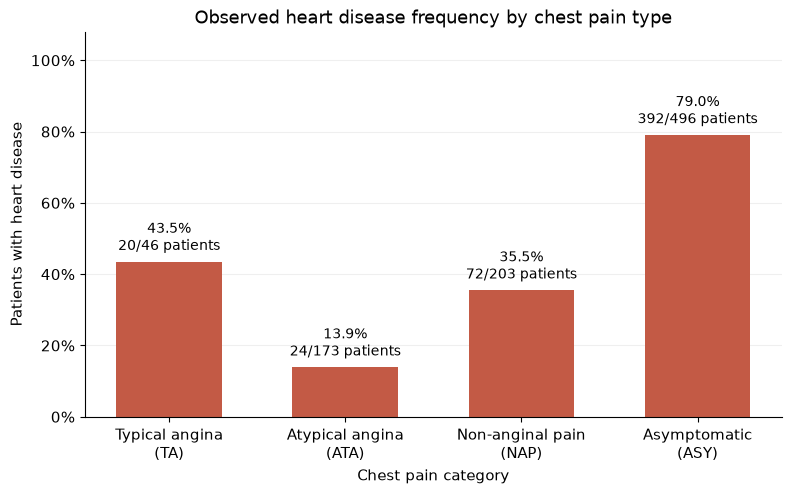

In [21]:
# Mean of a binary 0/1 target equals the fraction with HeartDisease=1.
order = ["TA", "ATA", "NAP", "ASY"]
stats = df.groupby("ChestPainType")["HeartDisease"].agg(["mean", "count", "sum"]).reindex(order)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(order, stats["mean"] * 100, color=colors[1], width=0.6)
for bar, row in zip(bars, stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{row.mean:.1%}\n{int(row.sum)}/{int(row.count)} patients",
            ha="center", va="bottom", fontsize=10)
ax.set_xticks(range(4), ["Typical angina\n(TA)", "Atypical angina\n(ATA)",
                       "Non-anginal pain\n(NAP)", "Asymptomatic\n(ASY)"])
ax.set(title="Observed heart disease frequency by chest pain type",
       xlabel="Chest pain category", ylabel="Patients with heart disease", ylim=(0, 108))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)


Plot 3: Compare angina states within each ST slope. These are empirical conditional frequencies, not Bayesian network query results.

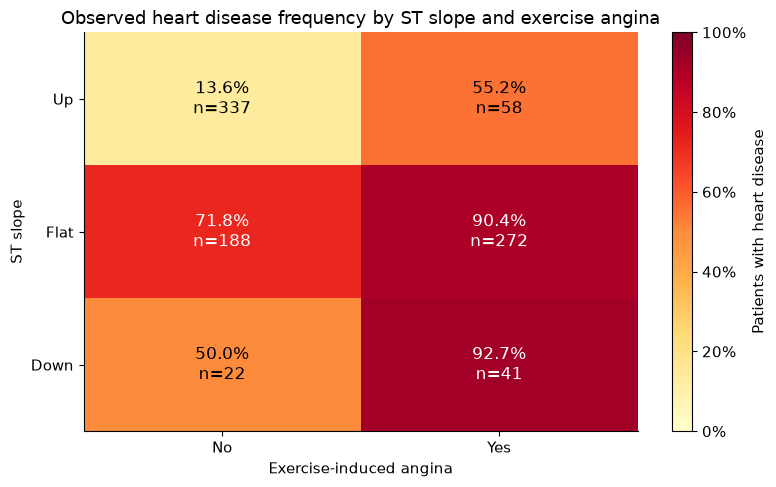

In [22]:
# Each cell estimates an observed P(HeartDisease=1 | two categorical features).
rates = df.pivot_table(index="ST_Slope", columns="ExerciseAngina",
                      values="HeartDisease", aggfunc="mean").reindex(index=["Up", "Flat", "Down"], columns=["N", "Y"])
counts = df.pivot_table(index="ST_Slope", columns="ExerciseAngina",
                       values="HeartDisease", aggfunc="count").reindex(index=rates.index, columns=rates.columns)
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(rates.to_numpy() * 100, cmap="YlOrRd", vmin=0, vmax=100, aspect="auto")
for i in range(len(rates.index)):
    for j in range(len(rates.columns)):
        value, n = rates.iloc[i, j], counts.iloc[i, j]
        text = f"{value:.1%}\nn={int(n)}" if pd.notna(value) else "No observations"
        ax.text(j, i, text, ha="center", va="center",
                color="white" if pd.notna(value) and value > 0.65 else "black", fontsize=12)
ax.set_xticks([0, 1], ["No", "Yes"])
ax.set_yticks([0, 1, 2], rates.index)
ax.set(title="Observed heart disease frequency by ST slope and exercise angina",
       xlabel="Exercise-induced angina", ylabel="ST slope")
fig.colorbar(im, ax=ax, format=PercentFormatter(100), label="Patients with heart disease")
save_plot(fig, "03_st_slope_exercise_angina.png")


Plot 4: Compare medians, spreads, and overlap. A box spans the middle 50%; whiskers extend to observations within 1.5 times the interquartile range. Points beyond them are not automatically errors.

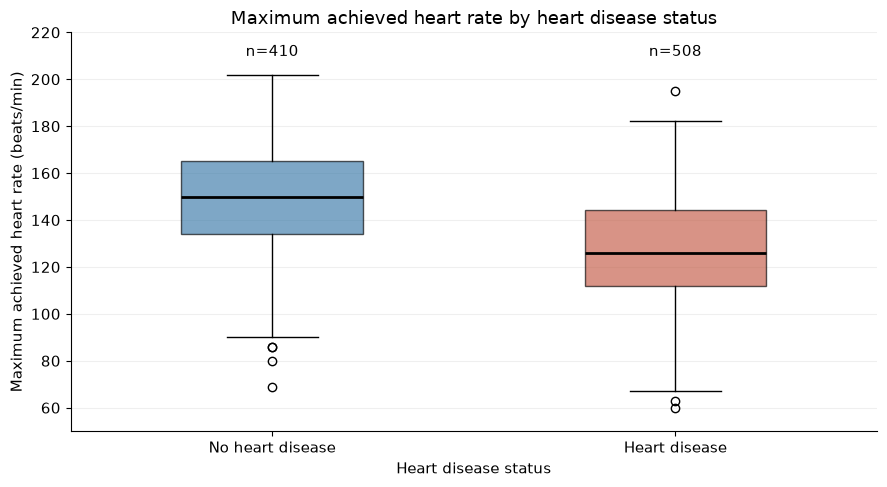

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
groups = [df.loc[df["HeartDisease"].eq(k), "MaxHR"].dropna() for k in [0, 1]]
boxes = ax.boxplot(groups, tick_labels=["No heart disease", "Heart disease"],
                   patch_artist=True, widths=0.45,
                   medianprops={"color": "black", "linewidth": 2})
for box, color in zip(boxes["boxes"], colors):
    box.set_facecolor(color)
    box.set_alpha(0.65)
for pos, values in enumerate(groups, 1):
    ax.text(pos, 0.97, f"n={len(values)}", transform=ax.get_xaxis_transform(),
            ha="center", va="top")
ax.set(title="Maximum achieved heart rate by heart disease status",
       xlabel="Heart disease status", ylabel="Maximum achieved heart rate (beats/min)",
       ylim=(50, 220))
ax.grid(axis="y", alpha=0.2)
save_plot(fig, "04_maxhr_by_heart_disease.png")


### Your interpretation
Write your own 3–5 sentence summary here after inspecting the plots.

2. Bayesian Network Structure Learning
    * Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
    * Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

`Your answer here`

3. Parameter Learning & Clinical Inference
    * Fit the conditional probability tables (CPTs) on the full data, then perform and interpret these five queries (show the numerical result + 2–3 sentence interpretation for each):

        **a) P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat'**
      
        **b) Same patient but with ExerciseAngina=1**
      
        **c) P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low')**
      
        **d) P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0)**
      
        **e) Full diagnostic: P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High')**

`Your answer here`

4. Turn your Bayesian Network into a probabilistic classifier
    * For each patient, compute P(HeartDisease=1 | all observed features)
    * Predict 1 if probability > 0.5
    * Report accuracy and AUC (optional but encouraged: use a 70/30 train/test split so numbers are realistic)

`Your answer here`

5. Answer both questions clearly:
    * Why might a hospital or cardiologist prefer your Bayesian Network over a neural network or XGBoost that has 3–5% higher accuracy?
    * Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice (a 30-second Google is allowed – just cite your source).

`Your answer here`